# Aula de elementos finitos (29/09)

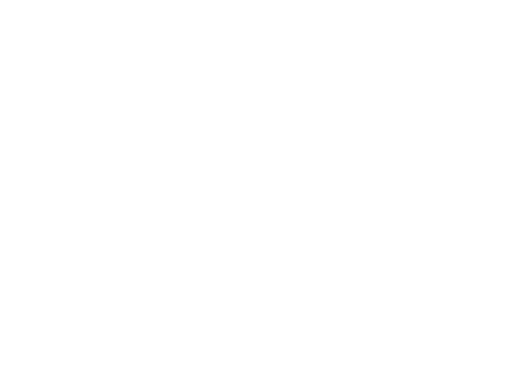

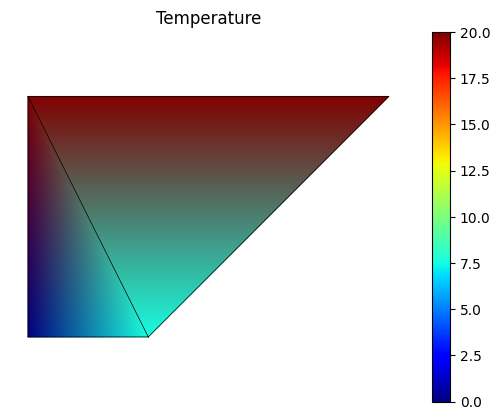

In [ ]:
from tkinter import W
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import spsolve
from scipy import sparse, linalg

class HT3():
    def __init__(self, nodes): #self está relacionado com o objeto
        self.nodes = nodes
        self.props = 0.0

    def Kmatrix(self, coords):
        x = coords[self.nodes, 0]
        y = coords[self.nodes, 1]

        B = np.zeros((2,3))
        B[0][0] = y[1] - y[2]
        B[0][1] = y[2] - y[0]
        B[0][2] = y[0] - y[1]

        B[1][0] = x[2] - x[1]
        B[1][1] = x[0] - x[2]
        B[1][2] = x[1] - x[0]

        A = 0.5 * (x[0] * y[1] + y[0] * x[2] + x[1] * y[2] - x[2] * y[1] - x[0] * y[2] - x[1] * y[0] ) #Metade do determinante
        B = (1.0 / (2 * A)) * B
        K = self.props * B.T @ B * A

        self.area = A
        self.centroid = [np.mean(x), np.mean(y)]

        ind_rows = [self.nodes[0], self.nodes[0], self.nodes[0], self.nodes[1], self.nodes[1], self.nodes[2]]
        ind_cols = [self.nodes[0], self.nodes[1], self.nodes[2], self.nodes[1], self.nodes[2], self.nodes[2]]
        values = [K[0,0], K[0,1], K[0,2], K[1,1], K[1,2], K[2,2]]
        return ind_rows, ind_cols, values

coords = np.array([[0.0 ,0.0], [1.0, 0.0], [0.0, 2.0], [3.0,2]])
elem_1 = HT3([0, 1, 2])
elem_1.props = 1.0
elem_2 = HT3([1, 3, 2])
elem_2.props = 1.0

#K1 = elem_1.Kmatrix(coords)
#K2 = elem_2.Kmatrix(coords)

#print(K1)

#print(K2)

class fem2dht ():
    def __init__(self):
        self.nnodes = 0
        self.nelements = 0
        return

    def create_nodes(self, coords): # Create nodes (using a matrix approach)
        self.nodes = coords
        self.nnodes = len(self.nodes)
        return
    
    def create_elements(self, connectivities): # Create a list of elements
        self.elements = [] 
        self.connectivities = connectivities
        for item in connectivities:
            element = HT3(item)
            self.elements.append(element)
        self.nelements = len(self.elements)
        return
    
    def define_props(self, props):
        for i, element in enumerate(self.elements):
            element.props = props
        return
    
    def create_bc(self, bc_type, nodes, values):
        self.bcs_nodes = nodes
        self.bcs_values = values
        return

    def solve(self):
        rows = []
        cols = []
        values = []

        for element in self.elements:
            r, c, v = element.Kmatrix(self.nodes)
            rows.append(r)
            cols.append(c)
            values.append(v)

        rows = np.array(rows, dtype='int').flatten()
        cols = np.array(cols, dtype='int').flatten()
        values = np.array(values, dtype='int').flatten()

        K_global = sparse.csr_matrix((values, (rows, cols)), shape = ((self.nnodes, self.nnodes)))
        K_global = K_global + K_global.T - sparse.diags(K_global.diagonal(), dtype='float')

        self.K_global = K_global
        fglobal = np.zeros(self.nnodes)

        #Boudary conditions
        w = 1e20
        nbcs = len(self.bcs_nodes)
        for k in range(nbcs):
            node = self.bcs_nodes[k]
            fglobal[node] = self.bcs_values[k] * w
            K_global[node, node] += w

        self.K_global = K_global
        self.fglobal = fglobal
        self.T = spsolve(K_global, fglobal)
        return

    def plot(self):
        plt.figure()
        plt.triplot(self.nodes[:,0], self.nodes[:,1], self.connectivities, '-w', linewidth=0.5)
        plt.axis('off')
        plt.axis('equal')

        plt.figure()
        plt.tripcolor(self.nodes[:,0], self.nodes[:,1], self.connectivities, self.T, shading='gouraud', cmap='jet')
        plt.triplot(self.nodes[:,0], self.nodes[:,1], self.connectivities,'-k', linewidth=0.5)
        plt.colorbar()
        plt.axis('off')
        plt.axis('equal')
        plt.title('Temperature')

problem = fem2dht()
coords = np.array([[0.0 ,0.0], [1.0, 0.0], [0.0, 2.0], [3.0,2]])
connectivities = np.array([[0, 1, 2], [1, 3, 2]])

# (1) Geometry and mesh
problem.create_nodes(coords)
problem.create_elements(connectivities)

# (2) Propriedades
problem.define_props(5)

#Boudary conditions
nodes = [0, 2, 3]
values = [0, 20, 20]
problem.create_bc('T', nodes, values)

#(4) Solve
problem.solve()

#(5) Posrprocessing
problem.plot()


In [ ]:
from tkinter import W
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import spsolve
from scipy import sparse, linalg

class HT3():
    def __init__(self, nodes): #self está relacionado com o objeto
        self.nodes = nodes
        self.props = 0.0

    def Kmatrix(self, coords):
        x = coords[self.nodes, 0]
        y = coords[self.nodes, 1]

        B = np.zeros((2,3))
        B[0][0] = y[1] - y[2]
        B[0][1] = y[2] - y[0]
        B[0][2] = y[0] - y[1]

        B[1][0] = x[2] - x[1]
        B[1][1] = x[0] - x[2]
        B[1][2] = x[1] - x[0]

        A = 0.5 * (x[0] * y[1] + y[0] * x[2] + x[1] * y[2] - x[2] * y[1] - x[0] * y[2] - x[1] * y[0] ) #Metade do determinante
        B = (1.0 / (2 * A)) * B
        K = self.props * B.T @ B * A

        self.area = A
        self.centroid = [np.mean(x), np.mean(y)]

        ind_rows = [self.nodes[0], self.nodes[0], self.nodes[0], self.nodes[1], self.nodes[1], self.nodes[2]]
        ind_cols = [self.nodes[0], self.nodes[1], self.nodes[2], self.nodes[1], self.nodes[2], self.nodes[2]]
        values = [K[0,0], K[0,1], K[0,2], K[1,1], K[1,2], K[2,2]]
        return ind_rows, ind_cols, values

coords = np.array([[0.0 ,0.0], [1.0, 0.0], [0.0, 2.0], [3.0,2]])
elem_1 = HT3([0, 1, 2])
elem_1.props = 1.0
elem_2 = HT3([1, 3, 2])
elem_2.props = 1.0

#K1 = elem_1.Kmatrix(coords)
#K2 = elem_2.Kmatrix(coords)

#print(K1)

#print(K2)

class fem2dht ():
    def __init__(self):
        self.nnodes = 0
        self.nelements = 0
        return

    def create_nodes(self, coords): # Create nodes (using a matrix approach)
        self.nodes = coords
        self.nnodes = len(self.nodes)
        return
    
    def create_elements(self, connectivities): # Create a list of elements
        self.elements = [] 
        self.connectivities = connectivities
        for item in connectivities:
            element = HT3(item)
            self.elements.append(element)
        self.nelements = len(self.elements)
        return
    
    def define_props(self, props):
        for i, element in enumerate(self.elements):
            element.props = props
        return
    
    def create_bc(self, bc_type, nodes, values):
        self.bcs_nodes = nodes
        self.bcs_values = values
        return

    def solve(self):
        rows = []
        cols = []
        values = []

        for element in self.elements:
            r, c, v = element.Kmatrix(self.nodes)
            rows.append(r)
            cols.append(c)
            values.append(v)

        rows = np.array(rows, dtype='int').flatten()
        cols = np.array(cols, dtype='int').flatten()
        values = np.array(values, dtype='int').flatten()

        K_global = sparse.csr_matrix((values, (rows, cols)), shape = ((self.nnodes, self.nnodes)))
        K_global = K_global + K_global.T - sparse.diags(K_global.diagonal(), dtype='float')

        self.K_global = K_global
        fglobal = np.zeros(self.nnodes)

        #Boudary conditions
        w = 1e20
        nbcs = len(self.bcs_nodes)
        for k in range(nbcs):
            node = self.bcs_nodes[k]
            fglobal[node] = self.bcs_values[k] * w
            K_global[node, node] += w

        self.K_global = K_global
        self.fglobal = fglobal
        self.T = spsolve(K_global, fglobal)
        return

    def plot(self):
        plt.figure()
        plt.triplot(self.nodes[:,0], self.nodes[:,1], self.connectivities, '-w', linewidth=0.5)
        plt.axis('off')
        plt.axis('equal')

        plt.figure()
        plt.tripcolor(self.nodes[:,0], self.nodes[:,1], self.connectivities, self.T, shading='gouraud', cmap='jet')
        plt.triplot(self.nodes[:,0], self.nodes[:,1], self.connectivities,'-k', linewidth=0.5)
        plt.colorbar()
        plt.axis('off')
        plt.axis('equal')
        plt.title('Temperature')

problem = fem2dht()
coords = np.array([[0.0 ,0.0], [1.0, 0.0], [0.0, 2.0], [3.0,2]])
connectivities = np.array([[0, 1, 2], [1, 3, 2]])

# (1) Geometry and mesh
problem.create_nodes(coords)
problem.create_elements(connectivities)

# (2) Propriedades
problem.define_props(5)

#Boudary conditions
nodes = [0, 2, 3]
values = [0, 20, 20]
problem.create_bc('T', nodes, values)

#(4) Solve
problem.solve()

#(5) Posrprocessing
problem.plot()